In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

## 1.Data Collection 

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400
2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600
2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000
2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800
...,...,...,...,...,...
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400
2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600
2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000
2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800
2026-07-06,312.660004,314.200012,307.000000,307.359985,53546100


## 2.Data Exploration & Visualization

In [5]:
type(df)

pandas.DataFrame

In [6]:
df.shape

(2512, 5)

In [7]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2512.000000,2512.000000,2512.000000,2512.000000,2.512000e+03
mean,126.756096,128.031690,125.368160,126.639812,9.570082e+07
std,77.946186,78.725143,77.118946,77.877079,5.466477e+07
min,21.840704,21.968187,21.767856,21.786067,1.791060e+07
25%,45.653825,46.117577,45.301242,45.657112,5.650462e+07
50%,131.198112,132.694646,129.843963,131.646478,8.378170e+07
75%,182.714333,184.419605,180.917194,182.415130,1.155630e+08
max,315.200012,317.399994,309.649994,314.179993,4.479400e+08


In [9]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [10]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400
2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600
2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000
2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800


In [11]:
df = df.reset_index()

In [12]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
1,2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400
2,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600
3,2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000
4,2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800
...,...,...,...,...,...,...
2507,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2508,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2509,2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200


Text(0, 0.5, 'Close price')

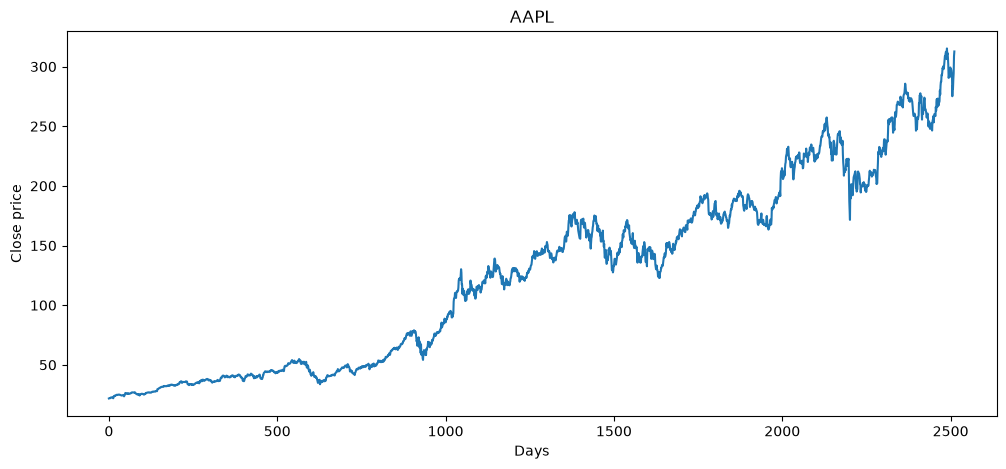

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

## 3.Feature Engineering

In [14]:
temp_df = [10,20,30,40,50,60,70,80,90,100]
print(sum(temp_df[2:7])/5)

50.0


In [15]:
df1 = pd.DataFrame([10,20,30,40,50,60,70,80,90,100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [16]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 days of Moving Average

In [17]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN
1,2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400,NaN
2,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN
3,2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000,NaN
4,2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800,NaN


In [18]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN
1,2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400,NaN
2,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN
3,2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000,NaN
4,2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800,NaN
...,...,...,...,...,...,...,...
98,2016-11-23,25.589352,25.653768,25.382299,25.619259,109705600,NaN
99,2016-11-25,25.718180,25.736585,25.524930,25.566341,45903600,24.940902
100,2016-11-28,25.667570,25.874623,25.626160,25.635362,108776000,24.979170


Text(0, 0.5, 'Price')

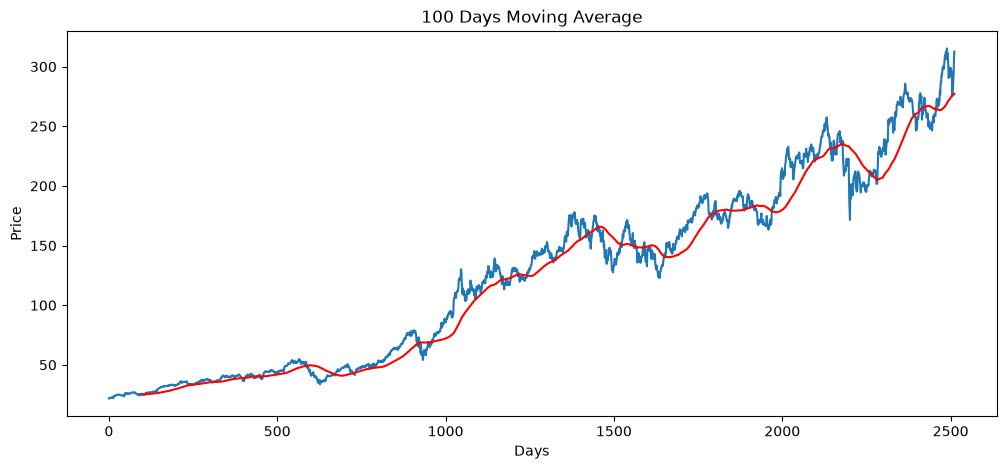

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df["MA_100"], 'r')
plt.title("100 Days Moving Average")
plt.xlabel('Days')
plt.ylabel('Price')

### 100 days of Moving Average

In [20]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
1,2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400,NaN,NaN
2,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN,NaN
3,2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000,NaN,NaN
4,2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800,NaN,NaN


In [21]:
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
1,2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400,NaN,NaN
2,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN,NaN
3,2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000,NaN,NaN
4,2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2017-04-20,32.911537,33.022443,32.615786,32.629649,93278400,29.667244,NaN
199,2017-04-21,32.872250,32.966980,32.775207,32.911529,69283600,29.738785,27.339843
200,2017-04-24,33.188808,33.260435,33.082521,33.156461,68537200,29.813997,27.396584


Text(0, 0.5, 'Price')

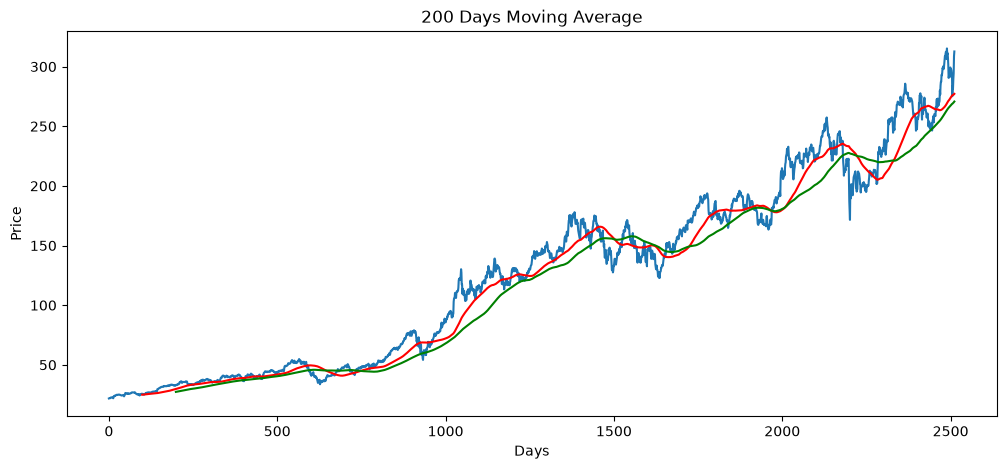

In [22]:
 plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df["MA_100"], 'r')
plt.plot(df["MA_200"], 'g')
plt.title("200 Days Moving Average")
plt.xlabel('Days')
plt.ylabel('Price')

In [23]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
1,2016-07-08,22.009174,22.056981,21.865756,21.965920,115648400,NaN,NaN
2,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN,NaN
3,2016-07-12,22.177631,22.241373,22.109338,22.120719,96670000,NaN,NaN
4,2016-07-13,22.052425,22.234544,22.045594,22.175356,103568800,NaN,NaN
...,...,...,...,...,...,...,...,...
2507,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000,276.108711,269.353488
2508,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200,276.242539,269.653382
2509,2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200,276.432355,269.958234


### Calculating % changed in each trading session

In [24]:
df["Percentage changed"] = df.Close.pct_change()


In [25]:
df[['Close', 'Percentage changed']]

Price,Close,Percentage changed
Ticker,AAPL,
0,21.840704,NaN
1,22.009174,0.007714
2,22.077465,0.003103
3,22.177631,0.004537
4,22.052425,-0.005646
...,...,...
2507,281.739990,-0.007189
2508,289.359985,0.027046
2509,294.380005,0.017349


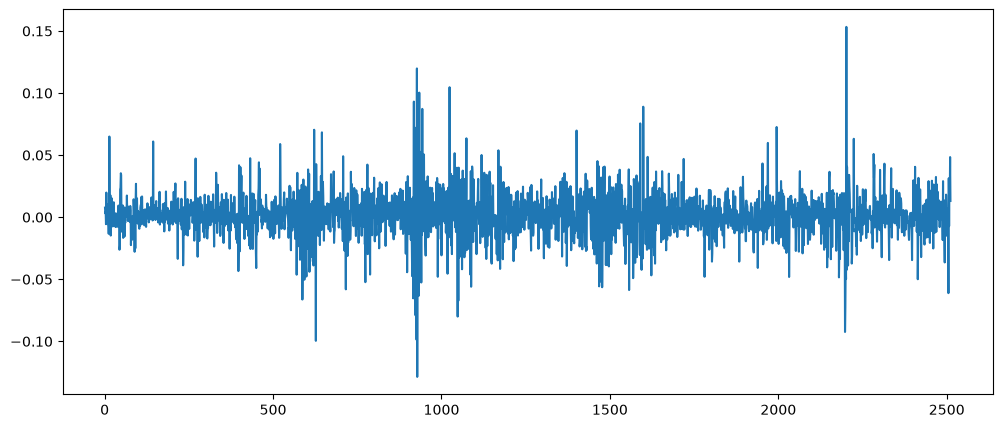

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage changed'])

## 4.Data Preprocessing

In [27]:
df.shape

(2512, 9)

In [28]:
# Splitting data into Training and Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])

print(data_training)
print(data_testing)

Ticker        AAPL
0        21.840704
1        22.009174
2        22.077465
3        22.177631
4        22.052425
...            ...
1753    182.708572
1754    185.459991
1755    186.633530
1756    186.968826
1757    191.288284

[1758 rows x 1 columns]
Ticker        AAPL
1758    189.799194
1759    188.684799
1760    189.158157
1761    188.043747
1762    186.002396
...            ...
2507    281.739990
2508    289.359985
2509    294.380005
2510    308.630005
2511    312.660004

[754 rows x 1 columns]


In [29]:
# Scaling down the data between 0 and 1

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [31]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00000000e+00],
       [9.94233039e-04],
       [1.39725272e-03],
       ...,
       [9.72529825e-01],
       [9.74508588e-01],
       [1.00000000e+00]], shape=(1758, 1))

In [32]:
type(data_training_array)

numpy.ndarray

In [33]:
data_training_array.shape

(1758, 1)

## 5.Sequence Creation

In [34]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [35]:
x_train

array([[[0.        ],
        [0.00099423],
        [0.00139725],
        ...,
        [0.02289664],
        [0.02212276],
        [0.02288304]],

       [[0.00099423],
        [0.00139725],
        [0.00198839],
        ...,
        [0.02212276],
        [0.02288304],
        [0.02258437]],

       [[0.00139725],
        [0.00198839],
        [0.00124948],
        ...,
        [0.02288304],
        [0.02258437],
        [0.02243502]],

       ...,

       [[0.74632092],
        [0.76767624],
        [0.75160165],
        ...,
        [0.95757276],
        [0.94936657],
        [0.96560415]],

       [[0.76767624],
        [0.75160165],
        [0.76854657],
        ...,
        [0.94936657],
        [0.96560415],
        [0.97252983]],

       [[0.75160165],
        [0.76854657],
        [0.7527044 ],
        ...,
        [0.96560415],
        [0.97252983],
        [0.97450859]]], shape=(1658, 100, 1))

In [36]:
y_train

array([0.02258437, 0.02243502, 0.02115879, ..., 0.97252983, 0.97450859,
       1.        ], shape=(1658,))

In [37]:
y_train.ndim

1

In [38]:
x_train.shape

(1658, 100, 1)

In [39]:
y_train.shape

(1658,)

## 6.Model Building

In [40]:
!pip install tensorflow

  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl (2.9 MB)
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [41]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [42]:
# ML Model
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input


In [43]:
model = Sequential()

model.add(Input(shape= (100, 1)))
model.add(LSTM(units=128, activation = 'tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(1))

## 7.Model Training

In [44]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0140
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 6.2020e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 5.8374e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 5.9357e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 5.8672e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 5.4287e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 5.0918e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 5.3721e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 5.3205e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 4.5800e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 4.9152e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 4.3036e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 4.4182e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 4.3621e-04
Epoch 15/50
5

In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 348,101 (1.33 MB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 232,068 (906.52 KB)

In [46]:
import tensorflow as tf
print(tf.__version__)


2.21.0


In [47]:
import keras
print(keras.__version__)

3.15.0


In [48]:
!pip install h5py

In [49]:
model.save('stock_prediction_model.keras')

## 8.Preparing Test Data

In [50]:
data_training.tail(100)

Ticker,AAPL
1658,152.069061
1659,149.384644
1660,148.352127
1661,148.716537
1662,151.513397
...,...
1753,182.708572
1754,185.459991
1755,186.633530
1756,186.968826


In [51]:
data_testing

Ticker,AAPL
1758,189.799194
1759,188.684799
1760,189.158157
1761,188.043747
1762,186.002396
...,...
2507,281.739990
2508,289.359985
2509,294.380005
2510,308.630005


In [52]:
past_100_days = data_training.tail(100)

In [53]:
past_100_days

Ticker,AAPL
1658,152.069061
1659,149.384644
1660,148.352127
1661,148.716537
1662,151.513397
...,...
1753,182.708572
1754,185.459991
1755,186.633530
1756,186.968826


In [54]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,152.069061
1,149.384644
2,148.352127
3,148.716537
4,151.513397
...,...
849,281.739990
850,289.359985
851,294.380005
852,308.630005


In [55]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.05209831],
       [0.03650002],
       [0.03050039],
       [0.03261787],
       [0.04886952],
       [0.04514989],
       [0.05733852],
       [0.04806835],
       [0.04143035],
       [0.01814002],
       [0.02060071],
       [0.02340462],
       [0.0080115 ],
       [0.01493553],
       [0.01201707],
       [0.        ],
       [0.00343333],
       [0.03273215],
       [0.04875515],
       [0.03599401],
       [0.04326162],
       [0.03021445],
       [0.01825449],
       [0.02952766],
       [0.0416591 ],
       [0.04394814],
       [0.06031417],
       [0.05545034],
       [0.0691842 ],
       [0.07994251],
       [0.07164472],
       [0.07793932],
       [0.08549296],
       [0.07422005],
       [0.07061453],
       [0.08846896],
       [0.09756748],
       [0.11210216],
       [0.11936985],
       [0.11627991],
       [0.1055788 ],
       [0.11072902],
       [0.09567903],
       [0.08864026],
       [0.08463487],
       [0.11587915],
       [0.11387623],
       [0.113

In [56]:
input_data.shape

(854, 1)

In [57]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i,0])

In [58]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [59]:
x_test

array([[[0.05209831],
        [0.03650002],
        [0.03050039],
        ...,
        [0.25294136],
        [0.25488966],
        [0.27998865]],

       [[0.03650002],
        [0.03050039],
        [0.03261787],
        ...,
        [0.25488966],
        [0.27998865],
        [0.27133602]],

       [[0.03050039],
        [0.03261787],
        [0.04886952],
        ...,
        [0.27998865],
        [0.27133602],
        [0.26486063]],

       ...,

       [[0.76872527],
        [0.78154288],
        [0.76273371],
        ...,
        [0.81742837],
        [0.80557453],
        [0.84985188]],

       [[0.78154288],
        [0.76273371],
        [0.75727663],
        ...,
        [0.80557453],
        [0.84985188],
        [0.87902161]],

       [[0.76273371],
        [0.75727663],
        [0.76784235],
        ...,
        [0.84985188],
        [0.87902161],
        [0.96182379]]], shape=(754, 100, 1))

In [60]:
y_test

array([0.27133602, 0.26486063, 0.26761116, 0.26113568, 0.24927404,
       0.24623686, 0.25592127, 0.26033354, 0.26119313, 0.28010329,
       0.27861347, 0.28646395, 0.27517535, 0.26835612, 0.27299767,
       0.27798307, 0.28302565, 0.27569093, 0.29064721, 0.29420006,
       0.2893864 , 0.27202343, 0.26394376, 0.21133909, 0.19334598,
       0.19878977, 0.18956385, 0.18830305, 0.18864724, 0.19823004,
       0.18669646, 0.18164696, 0.16690019, 0.16971181, 0.17745829,
       0.18543424, 0.2077552 , 0.18055683, 0.19335263, 0.20241888,
       0.22496957, 0.24522503, 0.24648733, 0.25561085, 0.25698798,
       0.21802648, 0.18732757, 0.19088529, 0.1976562 , 0.18009773,
       0.16810522, 0.17688437, 0.17269544, 0.18968017, 0.19599225,
       0.17544988, 0.16649828, 0.17143323, 0.17883533, 0.15519451,
       0.14641519, 0.14790714, 0.15089094, 0.16546561, 0.15771931,
       0.16494914, 0.1721217 , 0.18692609, 0.19553324, 0.19209033,
       0.20018109, 0.20540259, 0.19472994, 0.19398383, 0.18497

## 9.Making Predictions

In [61]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step


In [62]:
y_predicted

array([[0.26743743],
       [0.27508953],
       [0.2761613 ],
       [0.2753579 ],
       [0.27221522],
       [0.2654476 ],
       [0.25871214],
       [0.25755426],
       [0.26038632],
       [0.26395777],
       [0.2727665 ],
       [0.2801731 ],
       [0.28703293],
       [0.287532  ],
       [0.28312358],
       [0.28015894],
       [0.28065878],
       [0.28402862],
       [0.284779  ],
       [0.2892682 ],
       [0.2949772 ],
       [0.29745838],
       [0.29184237],
       [0.28248927],
       [0.25774127],
       [0.230312  ],
       [0.21315105],
       [0.2023649 ],
       [0.19654633],
       [0.1941939 ],
       [0.19651374],
       [0.19635566],
       [0.19352181],
       [0.1860455 ],
       [0.17978235],
       [0.17816378],
       [0.18116911],
       [0.19163772],
       [0.19390243],
       [0.19572163],
       [0.19965659],
       [0.21017915],
       [0.22652641],
       [0.24057953],
       [0.25204283],
       [0.2592782 ],
       [0.24993165],
       [0.227

In [63]:
y_test

array([0.27133602, 0.26486063, 0.26761116, 0.26113568, 0.24927404,
       0.24623686, 0.25592127, 0.26033354, 0.26119313, 0.28010329,
       0.27861347, 0.28646395, 0.27517535, 0.26835612, 0.27299767,
       0.27798307, 0.28302565, 0.27569093, 0.29064721, 0.29420006,
       0.2893864 , 0.27202343, 0.26394376, 0.21133909, 0.19334598,
       0.19878977, 0.18956385, 0.18830305, 0.18864724, 0.19823004,
       0.18669646, 0.18164696, 0.16690019, 0.16971181, 0.17745829,
       0.18543424, 0.2077552 , 0.18055683, 0.19335263, 0.20241888,
       0.22496957, 0.24522503, 0.24648733, 0.25561085, 0.25698798,
       0.21802648, 0.18732757, 0.19088529, 0.1976562 , 0.18009773,
       0.16810522, 0.17688437, 0.17269544, 0.18968017, 0.19599225,
       0.17544988, 0.16649828, 0.17143323, 0.17883533, 0.15519451,
       0.14641519, 0.14790714, 0.15089094, 0.16546561, 0.15771931,
       0.16494914, 0.1721217 , 0.18692609, 0.19553324, 0.19209033,
       0.20018109, 0.20540259, 0.19472994, 0.19398383, 0.18497

In [64]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [65]:
y_predicted

array([189.12827, 190.44516, 190.62961, 190.49136, 189.9505 , 188.78581,
       187.62666, 187.4274 , 187.9148 , 188.52942, 190.04536, 191.32002,
       192.5006 , 192.58647, 191.8278 , 191.3176 , 191.40363, 191.98355,
       192.1127 , 192.88527, 193.86777, 194.29477, 193.32826, 191.71864,
       187.4596 , 182.73909, 179.78575, 177.92947, 176.92812, 176.52328,
       176.92252, 176.89531, 176.40761, 175.12096, 174.04309, 173.76454,
       174.28175, 176.08337, 176.47311, 176.7862 , 177.4634 , 179.27429,
       182.08759, 184.50609, 186.4789 , 187.72408, 186.11557, 182.29982,
       179.20724, 177.80087, 176.54788, 175.07579, 174.38077, 173.97697,
       174.63222, 175.82571, 175.80774, 174.81883, 173.99443, 173.8707 ,
       172.88544, 171.39539, 170.22032, 169.66145, 170.20645, 170.66203,
       171.27473, 172.1213 , 173.5514 , 175.24344, 176.3646 , 177.32242,
       178.21124, 178.26198, 177.9312 , 177.11241, 175.98691, 174.9907 ,
       173.61237, 172.52583, 172.00104, 171.18532, 

In [66]:
y_test

array([189.79919434, 188.68479919, 189.15815735, 188.04374695,
       186.00239563, 185.47970581, 187.1463623 , 187.90570068,
       188.05363464, 191.30801392, 191.05162048, 192.40266418,
       190.45993042, 189.28636169, 190.0851593 , 190.94313049,
       191.8109436 , 190.54866028, 193.12258911, 193.73402405,
       192.90560913, 189.91749573, 188.52700806, 179.47390747,
       176.37734985, 177.31420898, 175.72645569, 175.50947571,
       175.56871033, 177.21788025, 175.23298645, 174.36398315,
       171.82611084, 172.3099823 , 173.64312744, 175.01576233,
       178.85713196, 174.17637634, 176.37849426, 177.93876648,
       181.81967163, 185.30557251, 185.52281189, 187.09294128,
       187.3299408 , 180.62478638, 175.34159851, 175.95387268,
       177.11912537, 174.09736633, 172.03349304, 173.5443573 ,
       172.82345581, 175.74647522, 176.83276367, 173.29748535,
       171.75694275, 172.60623169, 173.88011169, 169.81159973,
       168.30070496, 168.5574646 , 169.07096863, 171.57

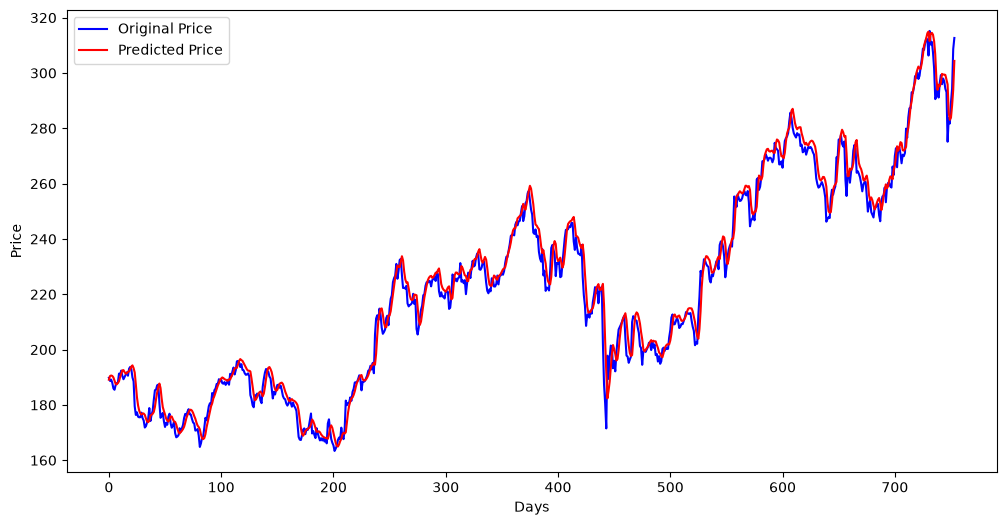

In [67]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_predicted, 'r', label = "Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

(160.0, 320.0)

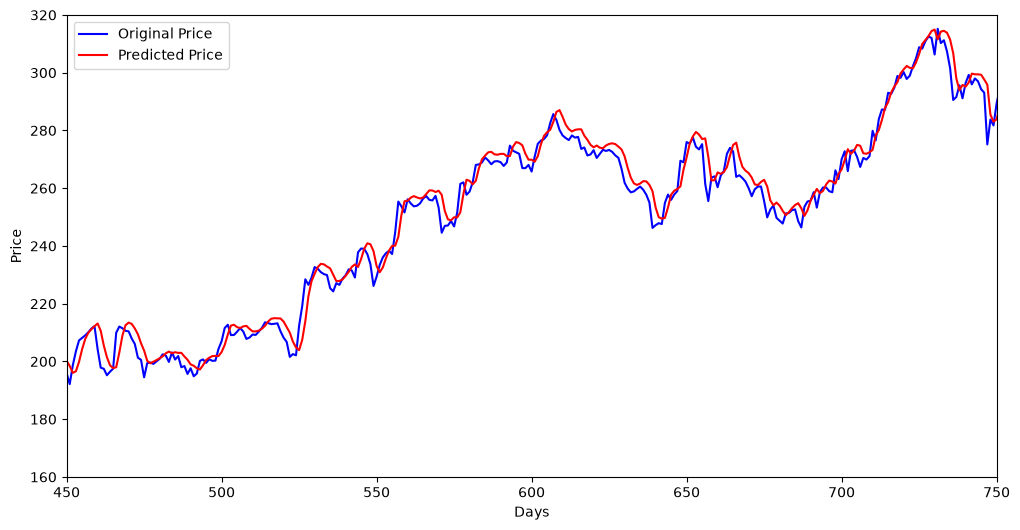

In [68]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_predicted, 'r', label = "Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.xlim(450, 750)
plt.ylim(160, 320)

## 10.Model Evaluation

In [69]:
# Mean Squared Error(MSE)

from sklearn.metrics import mean_squared_error, r2_score

In [70]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE):{mse}")

Mean Squared Error (MSE):22.60636433775398


In [71]:
# Root Mean Squared Erroe (RMSE)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE):{rmse}")

Root Mean Squared Error (RMSE):4.754615056737399


In [72]:
# R-Squared

r2 = r2_score(y_test, y_predicted)
print(f"R_Score: {r2}")

R_Score: 0.9834470706354023
